In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
%matplotlib widget


In [43]:
from scipy.constants import c

In [38]:
distance = np.linspace(200, 2000, 20)
elevation = np.linspace(0, 90, 20)
dist_elev_mesh = np.meshgrid(distance, elevation)
dist_elev_mesh[0].shape, dist_elev_mesh[1].shape

((20, 20), (20, 20))

In [50]:
center_freq = 436.5e6

In [51]:
antenna_angle_samples = np.arange(-np.pi, np.pi + np.pi/8, np.pi/8)
antenna_pattern_samples = 3 * np.cos(antenna_angle_samples / 2) ** 2
def antenna_pattern(angle):
    return np.interp(angle, antenna_angle_samples, antenna_pattern_samples)

In [52]:
def fspl_db(d, f):
    fspl = 20 * np.log10(d) + 20 * np.log10(f) - 147.55
    return fspl

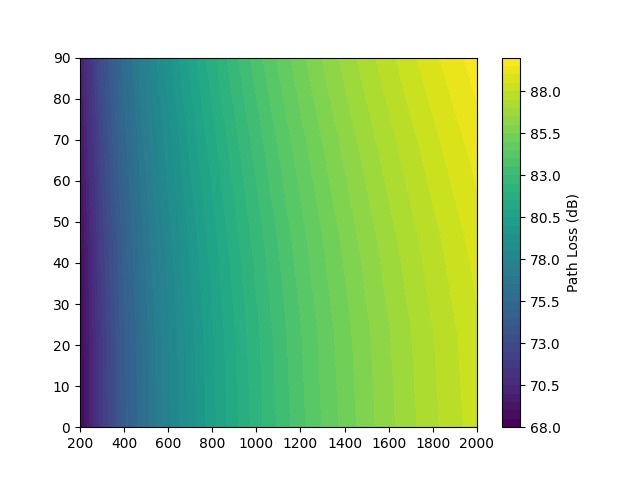

In [53]:
loss_mesh = fspl_db(dist_elev_mesh[0], center_freq) - antenna_pattern(np.radians(dist_elev_mesh[1]))
plt.figure()
plt.contourf(dist_elev_mesh[0], dist_elev_mesh[1], loss_mesh, levels=50)
plt.colorbar(label='Path Loss (dB)')
plt.show()

In [55]:
noise_figure_db = 2

noise_floor_dbm = -174 + 10 * np.log10(1e6) + noise_figure_db
print(f"Noise floor: {noise_floor_dbm:.2f} dBm")

Noise floor: -112.00 dBm
